In [2]:
!pip install mysql-connector-python


     |████████████████████████████████| 390 kB 4.0 MB/s eta 0:00:01
     |████████████████████████████████| 981 kB 35.0 MB/s eta 0:00:01


In [13]:
!pip install seaborn

     |████████████████████████████████| 293 kB 4.7 MB/s eta 0:00:01


In [14]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [82]:

# Connect to the database
conn = mysql.connector.connect(
    host="127.0.0.1",       
    port=3306,
    user="root",
    password="thudo1996",  ### your password
    database="movieRecSys"
)


#### 📊 Popularity Bias in Movie Ratings

**🔎Query Objective**: To explore how popularity bias affects perceived movie quality, we analyze each movie’s:
- Average rating (rounded to 2 decimals)
- Total number of ratings (used as a proxy for popularity)

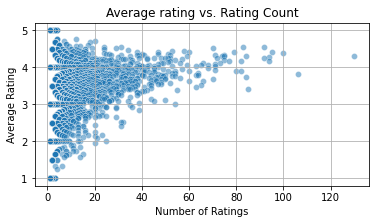

In [52]:
query2 = """
SELECT m.name, ROUND(AVG(r.rating), 2) AS avg_rate, COUNT(r.rating) as num_rate
FROM movies m
JOIN ratings r on m.movie_id = r.movie_id
GROUP BY m.name
ORDER BY avg_rate DESC;
"""
df_2 = pd.read_sql(query2, conn)

plt.figure(figsize=(6, 3))
sns.scatterplot(x='num_rate', y='avg_rate', data=df_2, alpha=0.5)
plt.title('Average rating vs. Rating Count')
plt.xlabel('Number of Ratings')
plt.ylabel('Average Rating')
plt.grid(True)
plt.show()


**📌Observations**: Our findings reveal a **highly skewed interaction distribution**: a small subset of movies—classified as popular—attract the vast majority of user ratings. These are likely well-known or widely promoted titles. In contrast, the vast majority of movies in the catalog receive minimal user engagement, indicating a long-tail distribution. These unpopular or underexposed movies often go unnoticed despite some of them achieving very high average ratings, suggesting the presence of hidden gems.

This pattern illustrates popularity bias in two key ways:

- Popular movies are seen and rated by more people, leading to more varied opinions.

- Niche or low-visibility movies are mostly rated by fans or highly interested viewers


**🧠Implications**:

- Marketing teams should intentionally surface and promote diverse or underexposed movies to encourage broader engagement and ratings.

- Recommendation systems should incorporate diversity-aware algorithms—such as long-tail boosting to ensure high-quality niche content is not systematically excluded.



#### 🕒 Recency Bias: Are Newer Movies Rated More Often?
**🔎Query Objective**: We examine the **number of ratings received by movies across different release years**. The query aggregates user rating counts by the year each movie was released, helping us identify which years produced the most actively rated content.

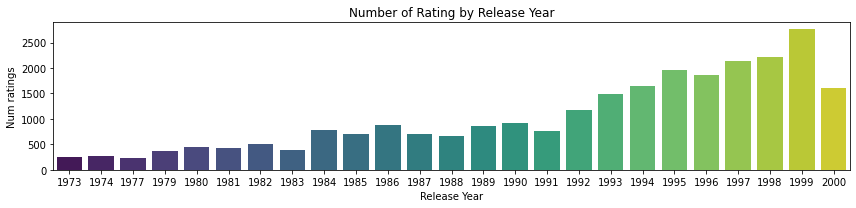

In [67]:
query3 = """
SELECT m.year, COUNT(r.rating) as num_rate
FROM ratings r
JOIN movies m on m.movie_id = r.movie_id
GROUP BY m.year
ORDER BY num_rate DESC
LIMIT 25
;
"""
df_3 = pd.read_sql(query3, conn)
### plot
plt.figure(figsize=(12, 3))
sns.barplot(x='year', y='num_rate', data=df_3, palette='viridis')
plt.title('Number of Rating by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Num ratings')
plt.tight_layout()
plt.show()

**📌Observations**: 

- The results show a clear trend: **recent movies consistently receive more ratings** compared to older ones. This indicates a **recency effect**, where users are more likely to watch and rate newer content.

- This suggests a strong recency bias - users tend to watch and rate newer content more often, likely due to:

    - Greater availability on streaming platforms
    - Promotional exposure
    - Social trends and novelty

**🧠Implications**:

-  We can boost user activitiy by continuously promoting newly released titles.

-  The recommendation system should include time-aware algorithms

### 🎬 Genre Popularity Based on Rating Volume

🔎 **Query Objective**: This analysis explores **which movie genres receive the most user attention**, as measured by the number of ratings submitted per genre. The query joins the **ratings**, **movie_genre**, and **genre** tables to count how many ratings are associated with each genre:

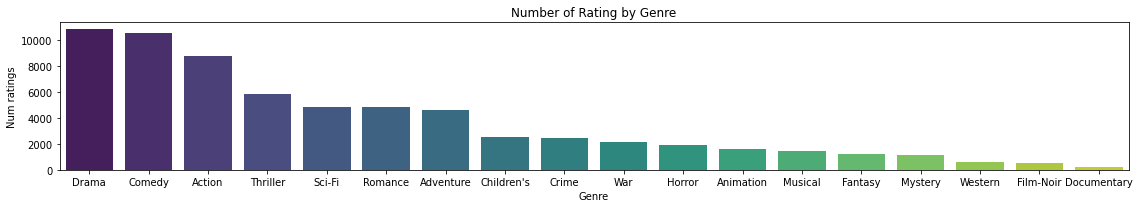

In [97]:
query4 = """
SELECT 
    g.genre, 
    COUNT(*) AS num_ratings
FROM ratings r
JOIN movie_genre mg ON mg.movie_id = r.movie_id
JOIN genre g ON g.genre_id = mg.genre_id
GROUP BY g.genre
ORDER BY num_ratings DESC;
"""
df_4 = pd.read_sql(query4, conn)
### plot
plt.figure(figsize=(16, 3))
sns.barplot(x='genre', y='num_ratings', data=df_4, palette='viridis')
plt.title('Number of Rating by Genre')
plt.xlabel('Genre')
plt.ylabel('Num ratings')
plt.tight_layout()
plt.show()

📌 Observations:

- Genres such as **Drama**, **Comedy**, and **Action** typically appear at the top, receiving the highest volume of user ratings.

- Niche genres like **Documentary**, **Film-Noir**, or **Western** tend to receive significantly fewer ratings.


🧠 Implications:

- High rating counts may reflect not just user preference, but platform exposure—popular genres are promoted more frequently.

- Recommendations can focus acquisition or licensing on high-engagement genres.

- Underrepresented genres could be strategically promoted to diversify user experiences and content discovery.

#### 🎞️ Temporal Genre Trends: Top 5 Genres by Year

**🔍 Query Objective**: This query investigates **how genre popularity evolves over time** by identifying the **top 5 most-rated genres for each year** based on user interactions.

In [132]:
query5 = """
WITH genre_counts AS (
    SELECT 
        YEAR(FROM_UNIXTIME(r.timestamp)) AS year,
        g.genre,
        COUNT(*) AS num_ratings,
        ROW_NUMBER() OVER (PARTITION BY YEAR(FROM_UNIXTIME(r.timestamp)) ORDER BY COUNT(*) DESC) AS ranking
    FROM ratings r
    JOIN movie_genre mg ON r.movie_id = mg.movie_id
    JOIN genre g ON mg.genre_id = g.genre_id
    GROUP BY year, g.genre
)
SELECT * FROM genre_counts
WHERE ranking <=5;

"""
df_5 = pd.read_sql(query5, conn)


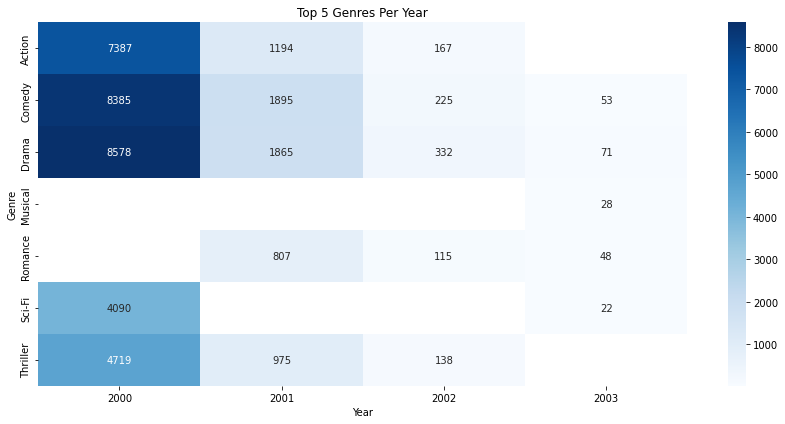

In [133]:
pivot_table = df_5.pivot(index='genre', columns='year', values='num_ratings')

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_table, annot=True, fmt='g', cmap='Blues')

plt.title('Top 5 Genres Per Year')
plt.xlabel('Year')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

📌 Observations:

- Certain genres like **Drama**, and **Comedy** may consistently appear in the top 5, indicating long-standing popularity.

- Some genres like **Musical** and **Sci-fi** may emerge or fade in specific years — highlighting the impact of major releases, societal trends, or platform curation.


🧠 Implications:

- High rating counts may reflect not just user preference, but platform exposure—popular genres are promoted more frequently.

- Recommendation systems should incorporate time-aware algorithm, adapting recommendations to current trends or seasonal preferences.

- Underrepresented genres could be strategically promoted to diversify user experiences and content discovery.